# 03. Modeling
Batch 1 학습 → Batch 2 테스트 (+ Batch 3 추가 검증)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
from config import DATA_DIR, RESULT_DIR
print(DATA_DIR)

/Users/parksihyun/Desktop/ess-battery-project/data


[정제] 배치별 제외 사유 (빈칸 = 사용)
excluded  kept  no_label  not_reach_EOL
batch                                  
b1          36         0             10
b2          39         8              0
b3          44         2              0 

[분할] Train 29 / Valid 7 (Batch 1) · Test 39 (Batch 2)

[성능] MAPE(%) · Gap(%p, (+) = 뒤쪽이 더 나쁨) · Target = 원논문 9.1%
                          Linear (variance)  ElasticNet (main)  ElasticNet (full)  RandomForest (main)  LightGBM (main)
Train (Batch 1 CV)                     9.16               5.77               6.78                 9.53             9.60
Valid (Batch 1 Hold-out)               8.09              19.03              18.31                12.82             9.39
Test (Batch 2)                        29.88              30.32              34.55                33.91            33.52
Gap (Train-Valid)                     -1.07              13.26              11.53                 3.29            -0.20
Gap (Valid-Test)                      21.79              11

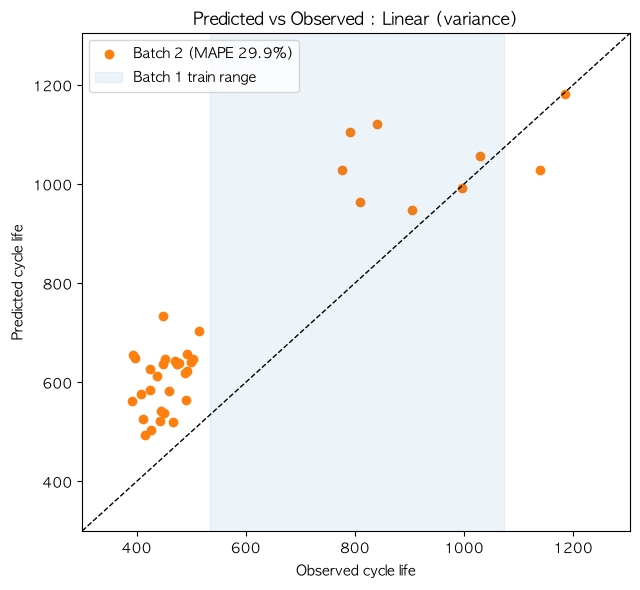

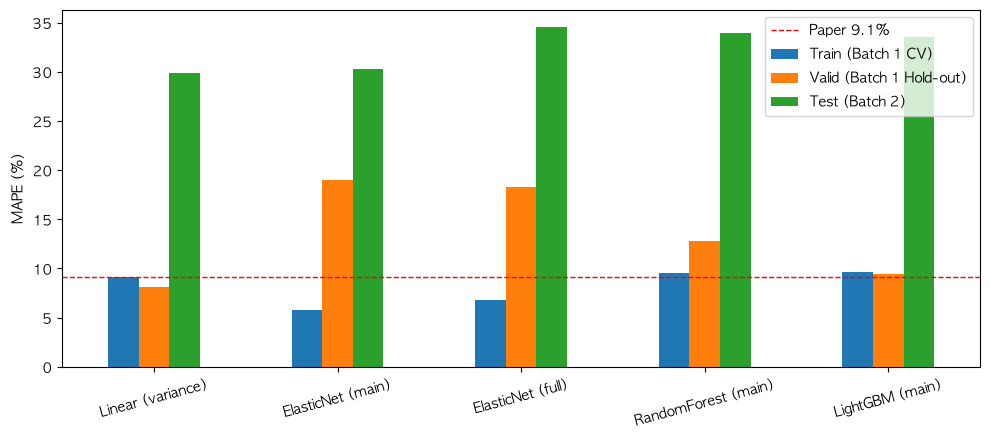

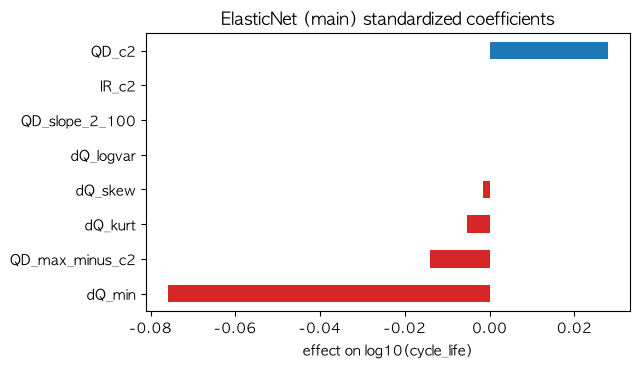


결과 저장 → /Users/parksihyun/Desktop/ess-battery-project/results


In [2]:
from train import run
out = run()

In [3]:
out['performance']

,Linear (variance),ElasticNet (main),ElasticNet (full),RandomForest (main),LightGBM (main)
Train (Batch 1 CV),9.16,5.77,6.78,9.53,9.60
Valid (Batch 1 Hold-out),8.09,19.03,18.31,12.82,9.39
Test (Batch 2),29.88,30.32,34.55,33.91,33.52
Gap (Train-Valid),-1.07,13.26,11.53,3.29,-0.20
Gap (Valid-Test),21.79,11.29,16.24,21.08,24.13
Gap (Target-Test),20.78,21.22,25.45,24.81,24.42


In [4]:
out['errors'].sort_values('APE(%)', ascending=False).head(10)

,cell,policy,cycle_life,dQ_logvar,pred,APE(%),signed(%),range,dQ_in_train_range
6,b2c6,3.6C(9%)-5C,393.0,-3.530040,656.0,66.9,66.9,below_train,True
15,b2c15,3.6C(9%)-5C,396.0,-3.516252,650.0,64.1,64.1,below_train,True
18,b2c18,5.2C(50%)-4.25C,449.0,-3.707303,735.0,63.7,63.7,below_train,True
2,b2c2,5.2C(50%)-4.25C,424.0,-3.460248,627.0,47.9,47.9,below_train,True
19,b2c19,6C(60%)-3C,392.0,-3.291958,563.0,43.6,43.6,below_train,False
27,b2c29,5.2C(58%)-4C,452.0,-3.508248,647.0,43.1,43.1,below_train,True
11,b2c11,5.2C(50%)-4.25C,449.0,-3.485393,637.0,41.9,41.9,below_train,True
21,b2c21,6C(60%)-3C,408.0,-3.326679,575.0,40.9,40.9,below_train,False
26,b2c28,4.8C(80%)-4.8C,437.0,-3.423411,612.0,40.0,40.0,below_train,True
9,b2c9,5.6C(26%)-4.5C-newstructure,791.0,-4.344426,1106.0,39.8,39.8,in_train,False
